In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importiung the dataset
df = pd.read_csv('../dataset/processed/spam.csv',encoding='latin-1')

#create the copy of the dataset
df_copy = df.copy(deep=True)
df_copy.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


## Data Cleaning

In [3]:
print(f'total number of rows and columns in the dataset: {df_copy.shape}')

total number of rows and columns in the dataset: (5572, 5)


In [4]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
# There are lot of missing values in column Unnamed:2,3,4 and
# we can't fill them{because lot of data is missing} so ,
# we drop the these 3 column 

df_copy=df_copy.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [6]:
df_copy.head(2)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [7]:
#Renaming the columns
df_copy.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [8]:
df_copy.columns

Index(['target', 'text'], dtype='object')

In [9]:
# first remove all the spaces and make every ham and spam lower
df_copy['target']=df_copy['target'].str.strip().str.lower()


In [10]:
# Now make ham=0 and span =1
df_copy['target']=df_copy['target'].map({'ham':0,'spam':1})

In [11]:
df_copy['target'].unique()

array([0, 1])

In [12]:
# now check the missing values
df_copy.isna().sum()

target    0
text      0
dtype: int64

In [13]:
# now check for duplicates values
print(f'total duplicate values:{df_copy.duplicated().sum()}')

total duplicate values:403


In [14]:
#just remove the duplicates 
df_copy.drop_duplicates(keep='first',inplace=True)

In [15]:
print(f'check again after process:{df_copy.duplicated().sum()}')

check again after process:0


In [16]:
df_copy.shape

(5169, 2)

## EDA

In [17]:
# Total % of the ham and spam in the dataset
df_copy['target'].value_counts(normalize=True)*100

target
0    87.366996
1    12.633004
Name: proportion, dtype: float64

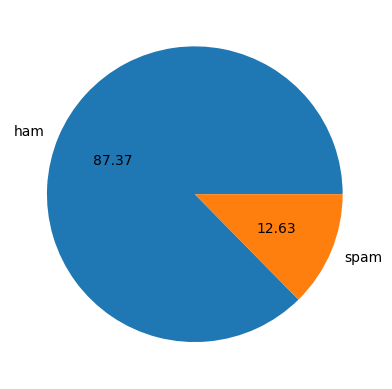

In [18]:
# represent on the pie
plt.pie(df_copy['target'].value_counts(),labels=['ham','spam'],autopct='%.2f')
plt.show()

In [19]:
# save the length of each text column in new column 
df_copy['num_characters']=df_copy['text'].apply(len)
#this even colun the len() counts the number of characters in the string (including spaces and punctuation).

In [20]:
# convert into token

import nltk
df_copy['text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [21]:
# find the len of the num of words
df_copy['num_words']=df_copy['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [22]:
# sentence token
df_copy['text'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [23]:
# save sentence token 
df_copy['num_sentences']=df_copy['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [24]:
df_copy.head(2)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2


## Data Visulization

In [25]:
df_copy[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
# for ham describle 
df_copy[df_copy['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
# for spam describe
df_copy[df_copy['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


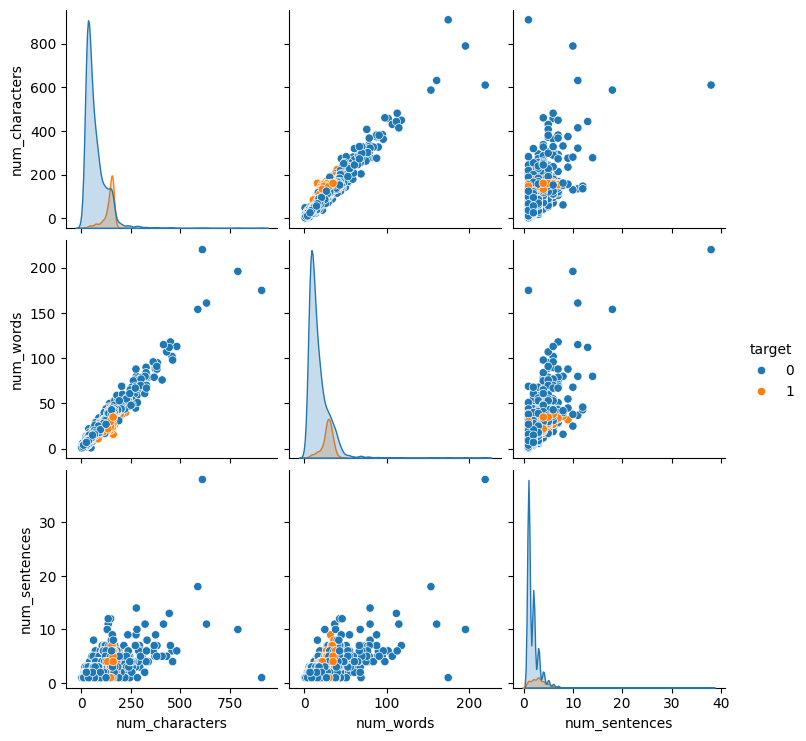

In [28]:
sns.pairplot(df_copy,hue='target')

In [29]:
import importlib.util
import sys
import pandas as pd

# Correct relative path
file_path = '../src/data_preprocessig.py'  # from notebooks folder to src folder

# Load module
spec = importlib.util.spec_from_file_location("data_preprocessig", file_path)
dp = importlib.util.module_from_spec(spec)
sys.modules["data_preprocessig"] = dp
spec.loader.exec_module(dp)

# Load CSV
df = pd.read_csv('../dataset/raw/spam.csv', encoding='latin-1')

# Apply text preprocessing
df_copy['transformed_text'] = df_copy['text'].apply(dp.transform_text)                    
df_copy.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [30]:
import os
import pandas as pd

# Make sure the folder exists
os.makedirs('../dataset/processed', exist_ok=True)  # creates folder if missing

# Save the cleaned DataFrame
df_copy.to_csv('../dataset/processed/spam_cleaned.csv', index=False)  # choose any name
print("Cleaned dataset saved as spam_cleaned.csv!")

Cleaned dataset saved as spam_cleaned.csv!


## WordCloud

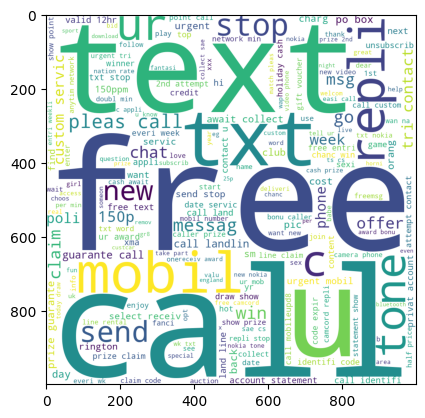

In [31]:
from wordcloud import WordCloud
# for spam
wc = WordCloud(width=1000,height=1000,min_font_size=10,background_color='white')
spam_wc=wc.generate(df_copy[df_copy['target']==1]['transformed_text'].str.cat(sep=' '))
plt.imshow(spam_wc) 

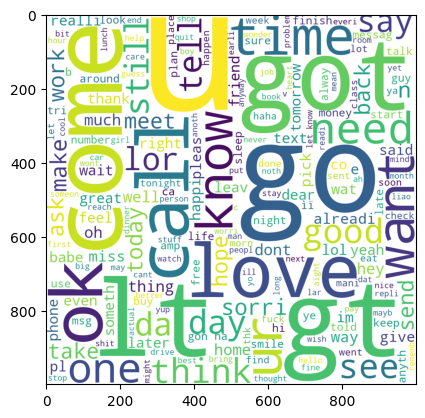

In [32]:
# for ham
ham_wc=wc.generate(df_copy[df_copy['target']==0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [33]:
# find most common 30 words used in spam

spam_corpus=[]
for msg in df_copy[df_copy['target']==1]['transformed_text'].tolist():

    for word in msg.split():
        spam_corpus.append(word)
        
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


In [34]:
# find the most common 30 words used in ham

spam_corpus=[]
for msg in df_copy[df_copy['target']==0]['transformed_text'].tolist():

    for word in msg.split():
        spam_corpus.append(word)
        
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


In [35]:
df = pd.read_csv('../dataset/processed/spam_cleaned.csv')

In [37]:
df.head(2)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [38]:
import sys

# Print Python version
print("Python version:", sys.version)

Python version: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [39]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0
